<>:19: SyntaxWarning: invalid escape sequence '\$'
<>:19: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_724/4022416510.py:19: SyntaxWarning: invalid escape sequence '\$'
  df_limpo['Preco_Limpo'] = df_limpo['Preco'].str.replace('R\$', '', regex=True)
/tmp/ipykernel_724/4022416510.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_limpo, x='Ano_Modelo', y='Preco_Limpo', palette='viridis', ax=axes[1])


📊 Dataset Original carregado com: 991 anúncios e 7 colunas.

✅ Limpeza Concluída! Ficaram 991 anúncios válidos para treinar a IA.



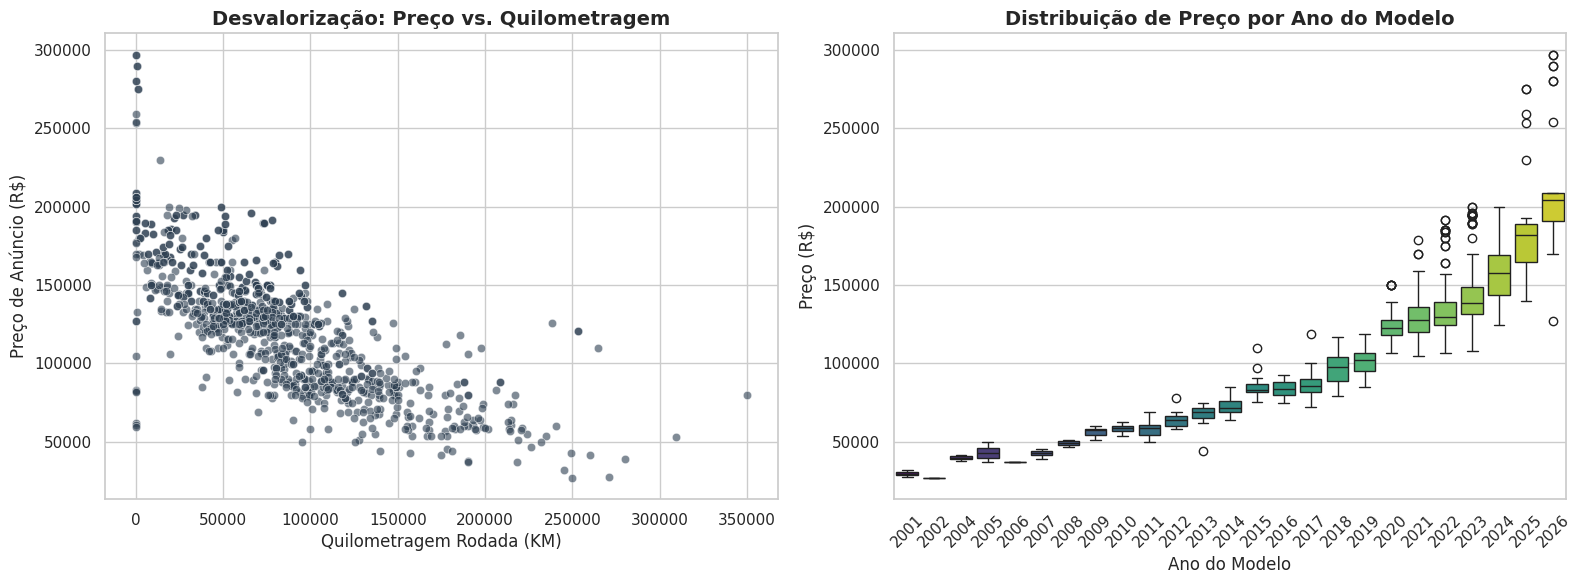

📁 Ficheiro 'dataset_corolla_limpo_ML.csv' guardado com sucesso no Colab!


In [2]:

# Projeto: Precificação de Veículos (Toyota Corolla Sedã - SP)
# Etapa: Limpeza de Dados e Análise Exploratória (EDA) - Entrega N1


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Dataset bruto
df = pd.read_csv('dataset_corolla_sp_bruto.csv')
print(f"📊 Dataset Original carregado com: {df.shape[0]} anúncios e {df.shape[1]} colunas.\n")

# 2. LIMPEZA DOS DADOS (Data Cleaning)

df_limpo = df.copy()

# Limpar Preço
df_limpo['Preco_Limpo'] = df_limpo['Preco'].str.replace('R\$', '', regex=True)
df_limpo['Preco_Limpo'] = df_limpo['Preco_Limpo'].str.replace(r'\s+', '', regex=True) # Remove espaços ocultos
df_limpo['Preco_Limpo'] = df_limpo['Preco_Limpo'].str.replace('.', '', regex=False)
df_limpo['Preco_Limpo'] = pd.to_numeric(df_limpo['Preco_Limpo'], errors='coerce')

# Limpar Quilometragem
df_limpo['KM_Limpo'] = df_limpo['Quilometragem'].str.replace(r'[Kk][Mm]', '', regex=True)
df_limpo['KM_Limpo'] = df_limpo['KM_Limpo'].str.replace(r'\s+', '', regex=True)
df_limpo['KM_Limpo'] = df_limpo['KM_Limpo'].str.replace('.', '', regex=False)
df_limpo['KM_Limpo'] = pd.to_numeric(df_limpo['KM_Limpo'], errors='coerce')

# Extrair o Ano do Modelo
df_limpo['Ano_Modelo'] = df_limpo['Ano'].astype(str).str.split('/').str[-1]
df_limpo['Ano_Modelo'] = pd.to_numeric(df_limpo['Ano_Modelo'], errors='coerce')

# Remover valores nulos ou inválidos
df_limpo = df_limpo.dropna(subset=['Preco_Limpo', 'KM_Limpo', 'Ano_Modelo'])

# Filtragem de Outliers (
# Considerando que um Corolla Sedan não custa menos de 20 mil nem mais de 300 mil
df_limpo = df_limpo[(df_limpo['Preco_Limpo'] > 20000) & (df_limpo['Preco_Limpo'] < 300000)]

print(f"✅ Limpeza Concluída! Ficaram {df_limpo.shape[0]} anúncios válidos para treinar a IA.\n")

# 3. ANÁLISE EXPLORATÓRIA VISUAL (Gráficos para o Relatório)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Dispersão (KM vs Preço)
sns.scatterplot(data=df_limpo, x='KM_Limpo', y='Preco_Limpo', alpha=0.6, color='#2c3e50', ax=axes[0])
axes[0].set_title('Desvalorização: Preço vs. Quilometragem', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Quilometragem Rodada (KM)', fontsize=12)
axes[0].set_ylabel('Preço de Anúncio (R$)', fontsize=12)
axes[0].ticklabel_format(style='plain', axis='both') # Evita notação científica

# Gráfico 2: Boxplot (Ano do Modelo vs Preço)
sns.boxplot(data=df_limpo, x='Ano_Modelo', y='Preco_Limpo', palette='viridis', ax=axes[1])
axes[1].set_title('Distribuição de Preço por Ano do Modelo', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Ano do Modelo', fontsize=12)
axes[1].set_ylabel('Preço (R$)', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# 4. SALVAR O DATASET LIMPO

df_limpo.to_csv('dataset_corolla_limpo_ML.csv', index=False, encoding='utf-8')
print("📁 Ficheiro 'dataset_corolla_limpo_ML.csv' guardado com sucesso no Colab!")